# Ch3.분류

이 장에서는 분류 시스템을 집중적으로 다룬다.

---

## 3.1 MNIST

여기서는 고등학생과 미국 인구 조사국 직원들이 손으로 쓴 70000개의 작은 숫자 이미지인 MNIST 데이터셋을 사용한다. 각 이미지에는 어떤 숫자를 나타내는지 레이블되어 있다. 사이킷런에서 제공하는 여러 헬퍼 함수를 사용해 잘 알려진 데이터셋을 내려받을 수 있다. MNIST도 그 중 하나이다. 다음은 ***openML.org***에서 MNIST 데이터셋을 내려받는 코드이다.

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',as_frame=False)

`sklearn.datasets` 패키지에 있는 함수는 대부분 세 종류이다. `fetch_openml()`과 같이 실전 데이터셋을 다운로드하기 위한 `fetch_*` 함수, 사이킷런에 번들로 포함된 소규모 데이터셋을 로드하기 위한 `load_*` 함수(따라서 인터넷으로 다운로드할 필요가 없다), 테스트에 유용한 가짜 데이터셋을 생성하기 위한 `make_*` 함수이다. 생성된 데이터셋은 일반적으로 넘파이 배열이고 입력과 타깃 데이터를 담은 `(X,y)` 튜플로 반환된다. `sklearn.utils.Bunch` 객체로 반환되는 데이터셋도 있다. 이 객체는 속성으로 다음과 같은 항목을 참조할 수 있는 딕셔너리이다.  
- `DESCR`: 데이터셋 설명  

- `data` : 입력 데이터, 일반적으로 2D 넘파이 배열  

- `target` : 레이블, 일반적으로 1D 넘파이 배열

`fetch_openml()` 함수는 조금 특이하게도 기본적으로 입력을 판다스 데이터프레임, 레이블은 판다스 시리즈로 반환한다. `fetch_openml()` 함수의 `as_frame` 매개변수 기본값은 `auto`로 데이터셋이 희소 행렬로 저장되어 있지 않다면 데이터프레임(입력 데이터)과 시리즈(레이블)를 반환한다. 하지만 MNIST 데이터셋은 이미지이므로 데이터프레임이 잘 맞지 않는다. 따라서 `as_frame=False`로 지정하여 넘파이 배열로 데이터를 받았다.

In [5]:
X,y = mnist.data, mnist.target

print(X)
print(X.shape)
print(y)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(70000, 784)
['5' '0' '4' ... '4' '5' '6']


이미지가 70000개 있고 각 이미지는 784개의 변수가 있다. 이미지가 28 x 28 픽셀이기 때문이다. 각각의 변수는 단순히 0 (흰색)부터 255(검은색)까지의 픽셀 강도를 나타낸다. 데이터셋에서 이미지 하나를 확인해본다. 샘플의 설명벡터를 추출해서 28 x 28 배열로 크기를 바꾸고 `matplotlib`의 `imshow()` 함수를 사용해 그리면 된다. `cmap='binary'`로 지정해 0을 흰색, 255를 검은색으로 나타내는 흑백 컬러 맵을 사용한다.

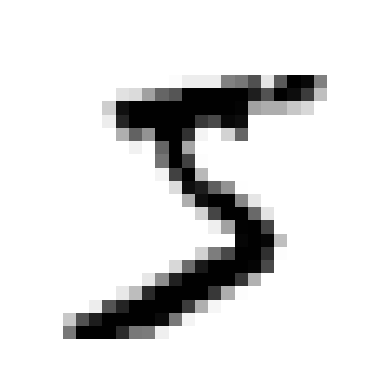

In [6]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()

사진을 보면 5로 보이고, 실제 레이블도 5이다.

데이터를 자세히 조사하기 전에 항상 테스트 세트를 만들고 따로 떼어놓아야 한다. 사실 `fetch_openml()`이 반환한 MNIST 데이터셋은 이미 훈련 세트(앞쪽 60000개 이미지)와 테스트 세트(뒤쪽 10000개 이미지)로 나뉘어있다.

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

훈련 세트는 이미 섞여 있어서 모든 교차 검증 폴드를 비슷하게 만든다. 하나의 폴드라도 특정 숫자가 누락되면 안된다. 더군다나 어떤 학습 알고리즘은 훈련 샘플의 순서에 민감해서 많은 비슷한 샘플이 연이어 나타나면 성능이 나빠진다. 데이터셋을 섞으면 이런 문제를 방지할 수 있다(다만 시계열 데이터 같이 섞으면 안되는 경우도 있다).

---

## 3.2 이진 분류기 훈련

문제를 단순화해서 하나의 숫자, 예를 들어 숫자 5만 식별해본다. 이 5 감지기는 5와 5가 아닌 두 개의 클래스를 구분할 수 있는 **이진 분류기**이다. 분류 작업을 위해 타겟 벡터를 만들어본다.

In [8]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

이제 분류 모델을 하나 선택해서 훈련시켜본다. 사이킷런의 `SDGClassifier` 클래스를 사용해 **확률적 경사 하강법(Stochastic Gradient Descent)** 분류기로 시작해본다. 이 분류기의 장점은 매우 큰 데이터셋을 효율적으로 처리할 수 있다는 점이다. SGD는 한 번에 하나씩 훈련 샘플을 독립적으로 처리할 수 있다. 그래서 SGD가 온라인 학습에 잘 들어맞는다. `SGDClassifier` 모델을 만들고 전체 훈련 세트를 사용해 훈련시켜본다.

In [9]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5);

이제 이 모델을 사용해 숫자 5의 이미지를 감지한다.

In [10]:
sgd_clf.predict([some_digit])

array([ True])

분류기는 이 이미지가 5를 나타낸다고 추측했다. 이 샘플에 대해서는 정확히 맞춘 것 같다. 이제 모델의 성능을 평가해본다.

---

## 3.3 성능 측정

분류는 회귀보다 사용할 수 있는 성능 지표가 훨씬 많다. 이번엔 여러가지 새로운 개념과 용어를 배워본다.

### 교차 검증을 사용한 정확도 측정

2장에서 실습했던 것처럼 교차 검증은 모델을 평가하는 좋은 방법이다. `cross_val_score()` 함수로 폴드가 3개인 k-fold 교차 검증을 사용해 SDGClassifier 모델을 평가해본다. k-fold 교차 검증은 훈련 세트를 k개 (여기서는 3개)의 폴드를 나누고, 평가를 위해 매번 다른 폴드를 떼어놓고 모델을 k번 훈련한다.

In [11]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

모든 교차 검증 폴드에 대해 정확도가 95% 이상이다. 모든 이미지를 가장 많이 등장하는 클래스로 분류하는 더미 분류기를 만들어 비교해본다.

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● DummyClassifier</strong><br>
    사이킷런의 <code>DummyClassifier</code>는 모델의 학습없이 <b>아무 의미 없는 기준선</b>을 만들어주는 클래스이다. 모델 성능 비교용이나 최소한의 모델 성능을 위한 기준선 역할을 하며, <code>strategy</code> 옵션을 통해 예측 방법을 지정할 수 있다.
</div>

In [12]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train,y_train_5);
print(any(dummy_clf.predict(X_train)))

False


`False`가 출력된다. 즉, `True`로 예측된 것이 없다.

In [13]:
cross_val_score(dummy_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

정확도가 90% 이상으로 나온다. 이미지의 10% 정도만 숫자 5기 때문에 무조건 5가 아니라고 예측하면 정확히 맞출 확률이 90%이다.

이 예제는 정확도를 분류기의 성능 측정 지표로 선호하지 않는 이유를 보여준다. 특히, **불균형한 데이터셋**을 다룰 때(즉, 어떤 클래스가 다른 것보다 월등히 많은 경우) 더욱 그렇다. 분류기의 성능을 평가하는 더 좋은 방법은 **오차 행렬(confusion matrix)** 을 조사하는 것이다.

### 오차 행렬

오차 행렬의 기본 아이디어는 모든 A/B 쌍에 대해 클래스 A의 샘플이 클래스 B로 분류된 횟수를 세는 것이다. 예를 들어 분류기가 숫자 8의 이미지를 0으로 잘못 분류한 횟수를 알고 싶다면 오차 행렬에서 8번째 행 0번 열을 보면 된다.

<div style="text-align: center;">
  <img src="https://db0dce98.rocketcdn.me/en/files/2023/09/Sans-titre-3_Plan-de-travail-1-1024x594.png" width="900"/>
  <p style="font-style: italic; text-align: center;">이진 분류에서의 오차 행렬<br>출처 :https://datascientest.com/en/confusion-matrix-what-is-it-and-how-do-i-use-it</p>
</div>

오차 행렬을 만들려면 실제 타겟과 비교할 수 있도록 예측값을 만들어야 한다. 테스트 세트로 예측을 만들 수 있지만, 테스트 세트는 가장 마지막에 분류기가 배포 준비를 마치고 나서 사용되기 때문에 여기서 사용할 수 없다. 대신 `cross_val_predict()` 함수를 사용할 수 있다.

In [14]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf,X_train,y_train_5, cv=3)

In [19]:
y_train_pred

array([ True, False, False, ...,  True, False, False])

`cross_val_score()` 함수처럼 `cross_val_predict()` 함수는 k-fold 교차 검증을 수행하지만 평가 점수를 반환하지 않고 각 테스트 폴드에서 얻은 예측을 반환한다. 즉, 훈련 세트의 모든 샘플에 대해 깨끗한 예측을 얻게 된다. 여기서 깨끗하다는 뜻은 모델이 훈련하는 동안 보지 못했던 데이터(Out-of-Sample)에 대해 예측했다는 의미이다.

이제 `confusion_matrix()` 함수를 사용해 오차 행렬을 만들 준비가 되었다. 타겟 클래스인 `y_train_5`와 예측 클래스인 `y_train_pred`를 넣고 호출하면 된다.

In [20]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5,y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

행렬의 행은 **실제 클래스**를 나타내고 열은 **예측한 클래스**를 나타낸다. 이 행렬의 첫 번째 행은 5가 아닌 이미지(Negative class)에 대한 것으로 53892개를 5가 아님으로 정확하게 분류했고 나머지 687개는 5라고 잘못 분류했다. 두 번째 행은 5 이미지(Positive class)에 대한 것으로, 1891개를 5가 아님으로 잘못 분류했고 나머지 3530개를 정확히 5라고 분류했다. 완벽한 분류기라면 진짜 양성과 진짜 음성만 가지고 있을 것이므로 오차 행렬의 주대각선만 0이 아닌 값이 된다.

오차 행렬이 많은 정보를 제공하지만, 더 요약된 지표가 필요하다. 살펴볼만한 것 하나는 양성 예측의 정확도이다. 이를 **정밀도(Precision)** 라고 한다.

$$
Precision=\frac{TP}{TP+FP}
$$

$TP$는 진짜 양성의 수이고, $FP$는 거짓 양성의 수이다. 식에서 알 수 있듯이, 이는 **모델이 양성이라고 예측한 샘플 중 실제 양성의 비율**이다.

가장 간단한 방법은 제일 확신이 높은 샘플에 대해 양성 예측을 하고 나머지는 모두 음성 예측을 하는 분류기를 만드는 것이다. 이 양성 예측이 맞는다면 분류기의 정밀도는 100%이다. 당연히 이런 분류기는 다른 모든 양성 샘플을 무시하기 때문에 그리 유용하지 않다. 정밀도는 **재현율(recall)** 이라는 또 다른 지표와 같이 사용하는 것이 일반적이다. 재현율은 분류기가 정확하게 감지한 양성 샘플의 비율로, **민감도(sensitivity)** 또는 **True Positive Rate,TPR** 이라고도 한다.

$$
Recall = \frac{TP}{TP+FN}
$$

$FN$은 거짓 음성의 수이다. 재현율은 **실제 양성 샘플 중, 모델이 올바르게 예측한 샘플의 비율**이다.

### 정밀도와 재현율

사이킷런은 정밀도와 재현율을 포함하여 분류기의 지표를 계산하는 여러 함수를 제공한다.

In [21]:
from sklearn.metrics import precision_score, recall_score
print('Precision:',precision_score(y_train_5, y_train_pred))
print('Recall:',recall_score(y_train_5,y_train_pred))

Precision: 0.8370879772350012
Recall: 0.6511713705958311


정확도에서 봤을 때만큼 성능이 좋아보이지는 않다. 5로 판별된 이미지 중 83.7%만 정확하다. 더군더나 전체 숫자 5에서 65.1%만 감지했다.

정밀도와 재현률을 $F_1\ Score$라고 하는 하나의 숫자로 만들면 편리하다. 특히 두 분류기를 비교할 때 그렇다. $F_1\ Score$는 정밀도와 재현율의 **조화 평균(Harmonic mean)** 이다. 보통의 평균은 모든 값을 동일하게 취급하지만 조화 평균은 **낮은 값에 훨씬 더 높은 비중을 둔다.** 결과적으로 분류기의 $F_1$ 점수가 높아지려면 재현율과 정밀도와 모두 높아야한다.

$$
F_1\ Score = \frac{2}{\frac{1}{Precision}+\frac{1}{Recall}}= 2\ \ast  \frac{Precision\ \ast\ Recall }{Precision\ + Recall} = \frac{TP}{TP+\frac{FN+FP}{2}}
$$

$F$ 점수의 일반화된 조화 평균 식은 다음과 같다.

$$
F = \frac{1}{\frac{\alpha}{Precision}+\frac{1-\alpha}{Recall}}= (\beta^2+1)\ \ast\ \frac{Precision\ \ast\ Recall }{\beta^2\ \ast\ Precision + Recall}
$$
$$
\beta^2 = \frac{1-\alpha}{\alpha}
$$

$\beta$가 1보다 크면 재현율이 강조되고 1보다 작으면 정밀도가 강조된다. $\beta$가 1일 때의 점수를 $F_1$ 점수라고 한다.

$F_1$ 점수를 계산하려면 `f1_score()` 함수를 호출하면 된다.

In [27]:
from sklearn.metrics import f1_score
print('F1 :',f1_score(y_train_5,y_train_pred))

F1 : 0.7325171197343846


정밀도와 재현율이 비슷한 분류기에서는 $F_1$ 점수가 높다. 하지만 이게 항상 바람직한 것은 아니다. 상황에 따라 정밀도가 중요할 수도 있고 재현율이 중요할 수도 있다. 예를 들어 어린아이에게 안전한 동영상을 걸러내는 분류기를 훈련시킨다고 가정해보자. 재현율은 높은데 정말 나쁜 동영상이 몇 개 노출되는 것보다 좋은 동영상이 많이 제외되더라도(낮은 재현율) 안전한 동영상만 노출시키는 (높은 정밀도) 분류기를 선호할 것이다. 이런 경우에는 분류기의 동영상 선택 결과를 확인하기 위해 사람이 참여하는 분석 파이프라인을 추가할 수도 있다.

다른 예로, 감시 카메라를 통해 좀도둑을 잡아내는 분류기를 훈련시킨다고 가정해본다. 분류기의 재현율이 99%라면 정밀도가 30%만 되더라도 괜찮을 것이다.

정밀도와 재현율 모두 얻을 수는 없다. 정밀도를 올리면 재현율이 줄고 그 반대도 마찬가지이다. 이를 **정밀도/재현율 트레이드오프(Trade-off)** 라고 한다.

### 정밀도/재현율 트레이드오프

`SGDClassifier`가 분류를 어떻게 결정하는지 살펴보며 정밀도/재현율 트레이드오프를 이해해본다. 이 분류기는 **결정 함수(Decision function)** 를 사용하여 각 샘플의 점수를 계산한다. 점수가 임계값보다 크면 샘플을 양성 클래스에 할당하고 그렇지 않으면 음성 클래스에 할당한다.

다음 그림에 가장 낮은 점수부터 가장 높은 점수까지 몇 개의 숫자를 나열했다. **결정 임곗값(Decision Threshold)** 이 가운데 (두 개의 숫자 5 사이) 화살표라고 가정해보자. 임곗값 오른쪽에 4개의 진짜 양성 (실제 숫자 5)과 하나의 거짓 양성 (실제 숫자 6)이 있다. 그렇기 때문에 이 임계값에서 정밀도는 80% (5개 중 4개)이다. 하지만 실제 숫자는 5는 6개고 분류기는 4개만 감지했으므로 재현율은 67% (6개 중 4개)이다. 이번에 임계값을 높이면 (임계값을 오른쪽 화살표로 옮기면) 거짓 양성 (숫자 6)이 진짜 음성이 되어 정밀도가 높아진다. 하지만 진짜 양성 하나가 거짓 음성이 되었으므로 재현율 50%로 줄어든다. 반대로 임계값을 내리면 재현율이 높아지고 정밀도가 줄어든다.

<center>

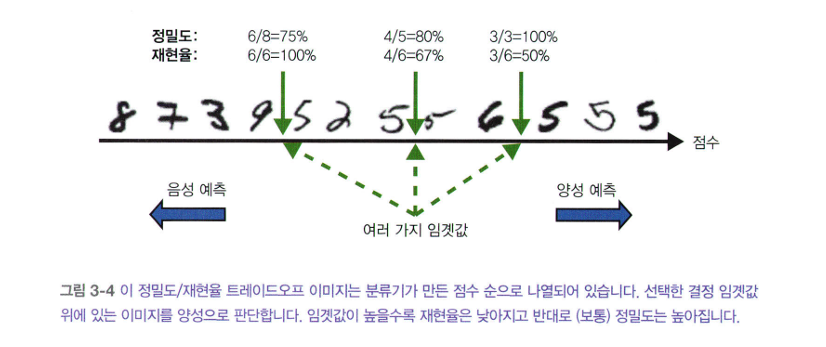

</center>

직관적으로 애기하면, 임곗값이 증가하면 양성이라고 판단되는 샘플이 줄어들 것이다. 그래서 모델이 정말로 확신하는 샘플만 양성으로 예측하게 된다. 정밀도의 식을 생각해보자. 분모의 $TP+FP$에서 임계값을 올리면 물론 $TP$도 줄어들지만, $FP$는 더 빠르게 감소한다. 따라서 **임곗값이 증가하면 정밀도는 증가**한다.
반면에 재현율은 임곗값이 증가하면 매우 보수적으로 예측해 $FN$이 증가하게 된다. 따라서 **임곗값이 증가하면 재현율은 감소**한다.

사이킷런에서 임계값을 직접 지정할 수는 없지만 예측에 사용한 점수는 확인할 수 있다. 분류기의 `predict()` 메서드 대신 `decision_function()` 메서드를 호출하면 각 샘플의 점수를 얻을 수 있다. 이 점수를 기반으로 원하는 임계값을 정해 예측을 만들 수 있다. `SGDClassifier`의 `decision_function`은 입력된 **데이터가 임계값(결정경계)에서 얼마만큼 떨어져 있는지**를 보여주는 함수이다.

In [32]:
y_scores = sgd_clf.decision_function([some_digit])
print(y_scores)

threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)

[2164.22030239]
[ True]


`SGDClassifier`의 임계값이 0이므로 `predict()` 메서드와 같은 결과인 `True`를 반환한다. 사실 `predict()` 메서드도 `decision_function()` 함수를 사용하여 0보다 큰 경우를 양성으로 예측한다. 임계값을 높여본다.

In [33]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

이 결과는 임계값을 높이면 재현율이 줄어든다는 것을 보여준다. 이미지가 실제로 숫자 5이고 임계값이 0일 때는 분류기가 이를 감지했지만 3000으로 높이면 이를 놓치게 된다.

적절한 임계값을 정하기 위해서는 먼저 `cross_value_predict()` 함수를 사용해 훈련 세트에 있는 모든 샘플의 점수를 구해야 한다. 하지만 이번에는 예측 결과가 아니라 결정 점수를 반환하도록 지정해야 한다.

In [36]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,method='decision_function')
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

이 점수로 `precision_recall_curve()` 함수를 사용하여 가능한 모든 임계값에 대하 정밀도와 재현율을 계산할 수 있다(이 함수는 무한한 임계값에 해당하는 값으로 마지막 정밀도에 1을, 마지막 재현율에 0을 추가한다).

In [39]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5,y_scores)

이제 맷플롯립을 이용해 임계값의 함수로 정밀도 재현율을 그릴 수 있다. 임계값이 3000일 때 그래프를 그려본다.

In [40]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')  
plt.rcParams['axes.unicode_minus'] = False 

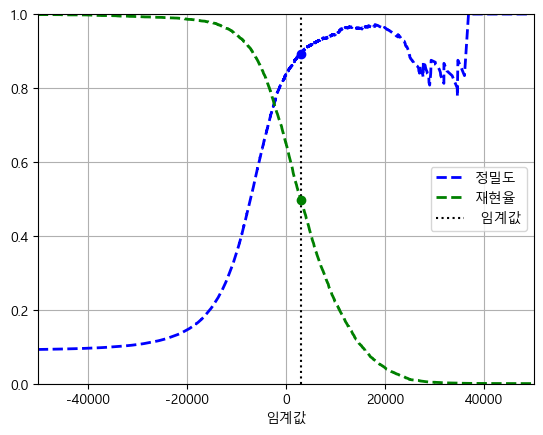

In [47]:
plt.plot(thresholds,precisions[:-1],'b--',label='정밀도',linewidth=2)
plt.plot(thresholds,recalls[:-1],'g--',label='재현율',linewidth=2)
plt.vlines(threshold,0,1.0,'k','dotted',label=' 임계값')

idx = (thresholds >= threshold).argmax()  # 첫 번째 index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("임계값")
plt.legend(loc="center right")

plt.show()

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    위의 그래프에서 정밀도 곡선이 재현율 곡선보다 더 울퉁불퉁하다. 이는 임계값을 올리더라도 정밀도가 낮아질 때가 가끔 있다(일반적으로 높아져야 한다). 위의 그림 3-4를 보면, 가운데 임계값에서 오른쪽으로 숫자 하나만큼 이동하면 정밀도는 80%에서 75%으로 줄어든다. 반면 재현율은 임계값이 올라감에 따라 줄어들 수밖에 없어 바로 위의 그래프처럼 부드러운 곡선이 된다.
</div>

이 임계값에서 정밀도는 약 90%이고 재현율은 약 50%이다. 좋은 정밀도/재현율 트레이드오프를 선택하는 방법은 재현율에 대한 정밀도 곡선을 그리는 것이다.

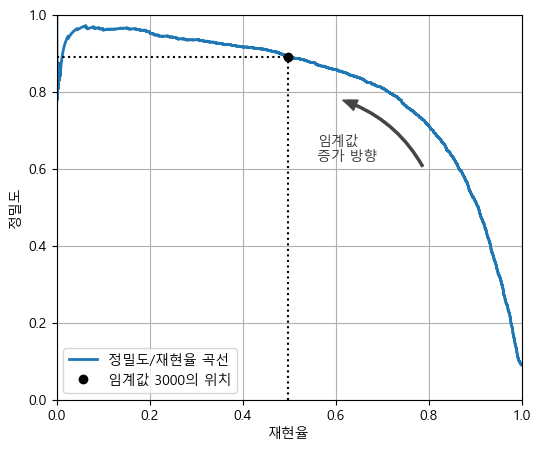

In [49]:
import matplotlib.patches as patches

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, linewidth=2, label="정밀도/재현율 곡선")

plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="임계값 3000의 위치")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "임계값\n증가 방향", color="#333333")
plt.xlabel("재현율")
plt.ylabel("정밀도")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

재현율 80% 근처에서 정밀도가 급격하게 줄어들기 시작한다. 이 하강점 직전을 정밀도/재현율 트레이드오프로 선택하는 것이 좋다. 예를 들어 재현율이 60% 정도인 지점이다. 물론 이런 선택은 프로젝트에 따라 달라진다.

정밀도 90%를 달성하는 것이 목표라고 가정해본다. 그래프에서 사용할 임계값을 찾을 수 있지만 정확하지 않다. 다른 방법은 정밀도가 최소 90%가 되는 가장 낮은 임계값을 찾는 것이다. 이를 위해 넘파이 배열의 `argmax()` 메서드를 사용할 수 있다. 이 메서드는 최대값의 첫 번째 인덱스를 반환한다. 여기에서는 첫 번째 `True` 값을 의미한다.

In [50]:
idx_for_90_precision = (precisions >= 0.9).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439557

훈련 세트에 대한 예측을 만들려면 분류기의 `predict()` 메서드를 호출하는 대신 다음 코드를 실행한다.

In [51]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

이 예측에 대한 정밀도와 재현율을 확인해본다.

In [52]:
print(precision_score(y_train_5, y_train_pred_90))

recall_at_90_precision = recall_score(y_train_5,y_train_pred_90)
print(recall_at_90_precision)

0.9000345901072293
0.4799852425751706


보다시피 임계값을 충분히 크게 지정하기만 하면 거의 모든 정밀도의 분류기를 손쉽게 만들 수 있다. 하지만 재현율이 너무 낮다면 높은 정밀도의 분류기는 유용하지 않을 것이다.

### ROC 곡선

**수신기 조작 특성(Receiver Operating Characteristic,ROC)** 곡선도 이진 분류에서 널리 사용되는 도구이다. 정밀도/재현율 곡선과 매우 비슷하지만, ROC 곡선은 **거짓 양성 비율(False Positive Rate,FPR)** 에 대한 **진짜 양성 비율(True Positive Rate,TPR,재현율)** 의 곡선이다. $FPR$(또는 fall-out이라고도 부른다)은 실제 음성 샘플 중 양성으로 오분류된 음성 샘플의 비율이다. 이는 1에서 음성으로 정확하게 분류한 음성 샘플의 비율인 **진짜 음성 비율(True Negative Rate,TNR)** 을 뺀 값이다. $TNR$을 **특이도(Specificity)** 라고도 한다. 그러므로 ROC 곡선을 **민감도(재현율)** 에 대한 1-특이도 그래프이다.

$$
False\ Positive\ Rate = \frac{FP}{FP+TN} = 1\ -\ \frac{TN}{TN+FP}\ =\ 1\ -\ Specificity
$$

ROC 곡선을 그리려면 먼저 `roc_curve()` 함수를 사용해 여러 임계값에서 TPR과 FPR을 계산해야 한다.

In [64]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5,y_scores)

그러면 맷플롯립을 사용해 $TPR$에 대한 $FPR$곡선을 나타낼 수 있다. 다음 코드는 아래의 그래프를 그린다. 90% 정밀도에 해당하는 지점을 찾기 위해 원하는 임계값의 인덱스를 찾아야 한다. 임계값이 내림차순으로 정렬되어 있기 때문에 첫 번째 라인에 >=가 아니라 <=를 사용한다.  
사이킷런의 `RocCurveDisplay` 클래스를 사용해 ROC 곡선을 그릴 수도 있다.

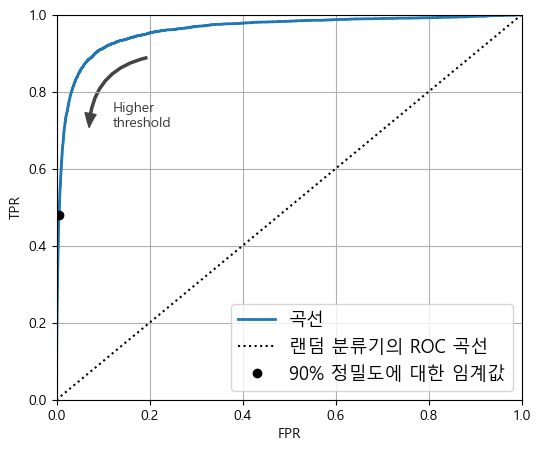

In [66]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  
plt.plot(fpr, tpr, linewidth=2, label="곡선")
plt.plot([0, 1], [0, 1], 'k:', label="랜덤 분류기의 ROC 곡선")
plt.plot([fpr_90], [tpr_90], "ko", label="90% 정밀도에 대한 임계값")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

여기에도 트레이드오프가 있다. 재현율($TPR$)이 높을수록 분류기가 만드는 거짓 양성 비율($FPR$)이 늘어난다. 점선은 완전히 랜덤 분류기의 ROC 곡선을 뜻한다. 좋은 분류기는 이 점선에서 최대한 멀리 떨어져 있어야 한다(왼쪽 위 모서리).

**곡선 아래의 면적(Area Under the Curve,AUC)** 을 측정해 분류기들을 비교할 수 있다. 완벽한 분류기는 ROC의 AUC가 1이고, 완전한 랜덤 분류기는 0.5이다. 사이킷런은 ROC의 AUC를 계산하는 함수를 제공한다.

In [67]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9604938554008616

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    일반적으로 <b>양성 클래스가 드물거나 거짓 음성보다 거짓 양성이 더 중요할 때 PR 곡선을 사용</b>하고 그렇지 않으면 ROC 곡선을 사용한다. 예를 들어 위의 ROC 곡선을 보면 매우 좋은 분류기라고 생각할 수 있다. 하지만 이는 음성에 비해 양성이 매우 적기 때문이다. 반면 PR 곡선은 분류기의 성능이 얼마만큼 개선될 수 있는지 보여준다. 즉, 실제로 위의 ROC는 오른쪽 위 모서리에 더 가까워질 수 있다.
</div>

`RandomForestClassifier`를 만들어 `SGDClassifier`의 PR 곡선과 $F_1$ 점수를 비교해본다.

In [68]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

`precision_recall_curve()` 함수는 각 샘플에 대한 레이블과 점수를 기대한다. 따라서 랜덤 포레스트 분류기를 훈련하여 각 샘플에 점수를 부여해야 한다. 하지만 `RandomForestClassifier`는 작동 방식 때문에 `decision_function()`을 제공하지 않는다. 다행히 각 샘플에 대한 클래스 확률을 반환하는 `predict_proba()` 메서드를 제공한다. 이 중 양성 클래스에 대한 확률을 점수로 사용할 수 있다. `cross_val_predict()` 함수를 호출하여 교차 검증으로 `RandomForestClassifier`를 훈련하고 모든 이미지에 대한 클래스 확률을 예측할 수 있다.

In [69]:
y_probas_forest = cross_val_predict(forest_clf,X_train,y_train_5,cv=3,method='predict_proba')

훈련 세트에 있는 처음 두 개의 이미지에 대한 클래스 확률을 확인해본다.

In [70]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

이 모델은 첫 번째 이미지를 89%의 확률로 양성이라고 예측한다. 그리고 두 번째 이미지를 99% 확률로 음성이라 예측한다. 모든 이미지는 양성 또는 음성 둘 중 하나이기 때문에 각 행의 확률을 더하면 100%가 된다.

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    이는 실제 확률이 아닌 추정 확률이다. 예를 들어 모델이 50%에서 60% 사이의 추정 확률로 양성으로 분류한 모든 이미지를 살펴보면 약 94%가 실제로 양성이다. 이 경우 모델의 추정 확률이 너무 낮았지만 모델 역시 과신할 수 있다. <code>sklearn.calibration</code> 패키지에는 추정 확률을 보정하여 실제 확률에 훨씬 가깝게 만드는 도구가 포함되어 있다.
</div>

두 번째 열에 양수 클래스에 대한 추정 확률이 포함되어 있으므로 이를 `precision_recall_curve()` 함수에 전달한다.

In [72]:
y_scores_forest = y_probas_forest[:,1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5,y_scores_forest)

이제 PR 곡선을 그릴 준비가 되었다. 첫 번째 PR 곡선도 그려서 서로 비교해본다.

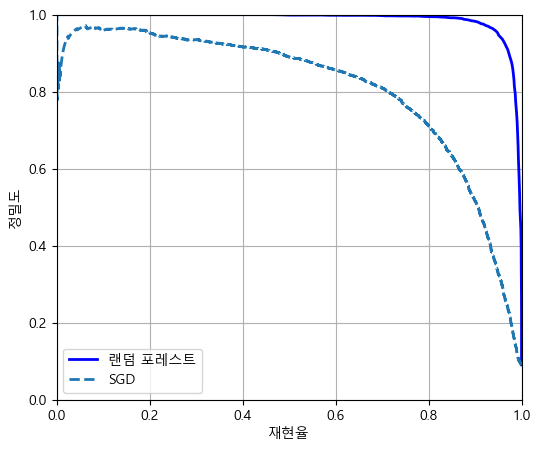

In [73]:
plt.figure(figsize=(6, 5))

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="랜덤 포레스트")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

plt.xlabel("재현율")
plt.ylabel("정밀도")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

위의 그림에서 볼 수 있듯이 `RandomForestClassifier`의 PR 곡선이 `SGDClassifier`의 곡선보다 훨씬 더 좋아 보인다. 즉, 오른쪽 위 모서리에 훨씬 가깝다. $F_1$ 점수와 ROC AUC 점수도 훨씬 더 우수하다.

In [77]:
y_train_pred_forest = y_probas_forest[:,1] >= 0.5
print('F1_forest:',f1_score(y_train_5,y_train_pred_forest))
print('AUC_forest:',roc_auc_score(y_train_5,y_scores_forest))
print('------------')
print('F1_SGD:',f1_score(y_train_5,y_train_pred))
print('AUC_SGD:',roc_auc_score(y_train_5,y_scores))

F1_forest: 0.9274509803921569
AUC_forest: 0.9983436731328145
------------
F1_SGD: 0.7325171197343846
AUC_SGD: 0.9604938554008616


정밀도와 재현율 점수를 계산하면 99.1% 정밀도와 86.6% 재현율이 나온다.

이제 이진 분류기를 훈련시키고, 작업에 맞는 적절한 지표를 선택하고, 교차 검증을 사용해 평가하고, 요구 사항에 맞는 정밀도/재현율 트레이드오프를 선택하고, 여러 가지 지표와 곡선을 사용해 여러 모델을 비교할 수 있게 되었다. 다음에는 숫자 5 이상을 감지해본다.

---

## 3.4 다중 분류

이진 분류기는 두 개의 클래스를 구별하는 반면 **다중 분류기(Multiclass classifier)** 또는 **다항 분류(Multinomial classifier)** 는 둘 이상의 클래스를 구별할 수 있다.

일부 알고리즘은 여러 개의 클래스를 직접 처리할 수 있지만 `SGDClassifier`와 같은 `SVC`같은 다른 알고리즘은 이진 분류만 가능하다. 하지만 이진 분류기를 여러 개 사용해 다중 클래스를 분류하는 기법도 많다.

예를 들어 특성 숫자만 구분하는 숫자별 이진 분류기 10개를 훈련시켜 클래스가 10개인 숫자 이미지 분류 시스템을 만들 수 있다. 이미지를 분류할 때 각 분류기의 결정 점수 중에서 가장 높은 것을 클래스로 선택하면 된다. 이를 **OVR(One-Versus-Rest)** 전략 또는 **OvA(One-versus-All)** 라고 한다.

또 다른 전략은 0과 1 구별, 0과 2 구별, 1과 2 구별 등과 같이 각 숫자의 조합마다 이진 분류기를 훈련시키는 것이다. 이를 **OvO(One-versus-One)** 전략이라고 한다. 클래스가 N개라면 분류기는 $\frac{N*(N-1)}{2}$개가 필요하다. MNIST 문제에서는 45개의 분류기를 훈련시켜야 한다는 뜻이다. 이미지 하나를 분류하려면 45개 분류기 모두를 통과시켜서 가장 많이 양성으로 분류된 클래스를 선택한다. OvO 전략의 주요 장점은 각 분류기의 훈련에 전체 훈련 세트 중 구별할 두 클래스에 해당하는 샘플만 있으면 된다는 점이다.

서포트 벡터 머신 같은 일부 알고리즘은 훈련 세트의 크기에 민감해서 큰 훈련 세트에서 몇 개의 분류기를 훈련시키는 것보다 작은 훈련 세트에서 많은 분류기를 훈련시키는 쪽이 빠르므로 OvO를 선호한다. 하지만 대부분의 이진 분류 알고리즘에서는 OvR을 선호한다.

다중 클래스 분류 작업에 이진 분류 알고리즘을 선택하면 사이킷런이 알고리즘에 따라 자동으로 OvR 또는 OvO를 실행한다. `sklearn.svm.SVC` 클래스를 사용해 서포트 벡터 머신 분류기를 테스트해본다. 처음 2000개의 이미지만 사용해 훈련한다. 그렇지 않으면 매우 오랜 시간이 걸릴 것이다.

In [78]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000],y_train[:2000]);

이 코드는 5를 구별한 타겟 클래스(`y_train_5`) 대신 0에서 9까지의 원래 타겟 클래스(`y_train`)를 사용해 `SVC`를 훈련시킨다. 2개보다 많은 10개의 클래스가 있기 때문에 사이킷런은 OvO 전략을 사용해 45개의 이진 분류기를 훈련한다. 이제 한 이미지에 대한 예측을 만들어본다.

In [79]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

이 코드는 실제로 클래스 쌍마다 하나씩 45번의 예측을 수행하여 가장 많은 쌍에서 승리한 클래스를 선택했다. `decision_function()` 메서드를 호출하면 샘플마다 총 10개의 점수(클래스마다 하나씩)를 반환하는 것을 볼 수 있다. 각 클래스는 동률 문제를 해결하기 위해 분류기 점수를 기반으로 각 쌍에서 이긴 횟수에 약간 조정 값을 더하거나 뺀 점수를 얻는다. 이는 `SVC` 클래스의 `break_ties` 매개변수를 `True`로 설정했을 때이다. 이 매개변수의 기본값은 `False`으로, 동률일 경우 첫 번째 클래스가 선택되고 더 빠르다.

In [80]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

가장 높은 점수는 9.3이고 이는 클래스 5에 해당한다.

In [81]:
class_id = some_digit_scores.argmax()
class_id

5

분류기가 훈련될 때 `classes_` 속성에 타겟 클래스의 리스트를 값으로 정렬하여 저장한다. MNIST의 경우 `classes_` 배열에 있는 각 클래스의 인덱스가 클래스의 값 자체와 같다. 즉, 인덱스 5에 해당하는 클래스의 값은 5이다. 하지만 일반적으로 이런 경우는 드물다. 다음과 같이 클래스 레이블을 확인해봐야 한다.

In [82]:
print(svm_clf.classes_)
print(svm_clf.classes_[class_id])

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
5


사이킷런에서 OvO나 OvR을 사용하도록 강제하려면 `OneVsOneClassifier`나 `OneVsRestClassifier`를 사용한다. 간단하게 이진 분류기 인스턴스를 만들어 객체를 생성할 때 전달하면 된다. 다음 코드는 `SVC` 기반으로 OvR 전략을 사용하는 다중 분류기를 만든다.

In [83]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000],y_train[:2000]);

예측을 만들고 훈련된 분류기 개수를 확인해본다.

In [84]:
ovr_clf.predict([some_digit])
len(ovr_clf.estimators_)

10

다중 분류 데이터셋에서 `SGDClassifier`를 훈련하고 예측을 만드는 것도 간단하다.

In [85]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train);
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

예측이 틀렸다. 이번에는 사이킷런이 OvR 전략을 사용했다. 10개의 클래스가 있기 때문에 10개의 이진 분류기를 훈련한다. `decision_function()` 메서드는 클래스마다 하나의 값을 반환한다. SGD 분류기가 각 클래스에 부여한 점수를 확인해본다.

In [86]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

이 결과에서 분류기가 예측 결과에 강한 확신을 보이고 있는 것을 알 수 있다. 대부분의 점수가 큰 음수이지만 클래스 3의 점수는 1824이다. 그리고 클래스 5도 -1386으로 그리 멀리 떨어져 있지 않다. 물론 이 분류기를 두 개 이상의 이미지에서 평가하고 싶을 것이다. 물론 이 분류기를 두 개 이상의 이미지에서 평가하고 싶을 것이다. 각 클래스마다 거의 같은 개수의 이미지가 있기 때문에 정확도 지표가 좋다. 이전처럼 `cross_val_score()` 함수를 사용해 이 모델을 평가해본다.

In [87]:
cross_val_score(sgd_clf,X_train,y_train,cv=3,scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

모든 테스트 폴드에서 85.8% 이상을 얻었다. 랜덤 분류기를 사용했다면 10% 정확도를 얻었을 것이므로 이 점수가 아주 나쁘지 않지만 성능을 더 높일 여지가 있다. 예를 들어 입력의 스케일을 조정하면 정확도를 89.1% 이상으로 높일 수 있다.

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype('float64'))
cross_val_score(sgd_clf,X_train_scaled,y_train,cv=3,scoring='accuracy')

array([0.8983, 0.891 , 0.9018])

## 3.5 오류 분석

데이터 준비 단계에서 가능한 선택 사항을 탐색하고, 여러 모델을 시도하고, 가장 좋은 몇 개를 골라 `GridSearchCV`를 사용해 하이퍼파라미터를 세밀하게 튜닝하고, 앞 장에서 한 것처럼 가능한 한 자동화한다. 이 절에서는 가능성이 높은 모델을 하나 찾았다고 가정하고 이 모델의 성능을 향상시킬 방법을 찾아본다. 한 가지 방법은 생성된 오류의 종류를 분석하는 것이다.

먼저 오차 행렬을 살펴보죠. 이를 위해 `cross_val_predict()` 함수를 사용해 예측을 만들고 `confusion_matrix()` 함수를 호출한다. 그 다음 앞에서 했던 것처럼 `confusion_matrix()` 함수에 레이블과 예측을 전달할 수 있다. 하지만 클래스가 2개가 아니라 10개라서 오차 행렬에 상당히 많은 숫자가 포함되므로 읽기 어려울 수 있다.

오차 행렬을 컬러 그래프로 나타내면 분석하기가 훨씬 쉽다. 그래프를 그리려면 다음과 같이 `ConfusionMatrixDisplay.from_predictions()` 함수를 사용하면 된다.

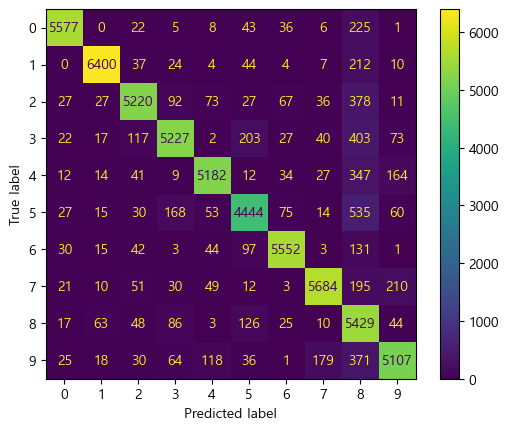

In [89]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf,X_train_scaled,y_train,cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

대부분의 이미지가 주대각선에 있는데, 이는 이미지가 올바르게 분류되었음을 의미한다. 5번 행과 5번 열의 대각선에 있는 셀은 다른 숫자보다 약간 더 어둡게 보인다. 이는 모델이 5에서 더 많은 오류를 범했거나 데이터 집합에 다른 숫자보다 5가 적기 때문일 것이다. 따라서 각 값을 해당 클래스 (`True` 레이블)의 총 이미지 수로 나누어 오차 행렬을 정규화하는 것이 중요하다. `normalize='True'`로 지정하면 이 작업을 간단히 수행할 수 있다. 또한 `value_format=".0%"` 매개변수를 지정하여 소수점 없이 백분율을 표시할 수도 있다.

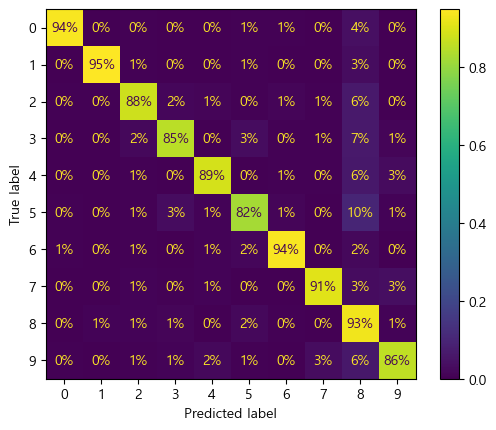

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,normalize='true',values_format=".0%")
plt.show()

이제 5 이미지의 82%만이 올바르게 분류되었다는 것을 쉽게 알 수 있다. 모델이 5 이미지에서 가장 많이 범한 오류는 8로 잘못 분류한 것인데 전체 5의 10%에서 이러한 오류가 발생했다. 하지만 8은 2%만이 5로 잘못 분류되었다. 즉, 오차 행렬은 일반적으로 대칭이 아니다. 주의 깊게 살펴보면 많은 숫자가 8로 잘못 분류되었지만 이 그래프를 보자마자 알 수 있는 것은 아니다. 오류를 더 눈에 띄게 만들고 싶다면 올바른 예측에 대한 가중치를 0으로 설정한다. 다음 코드는 바로 이 작업을 수행한다.

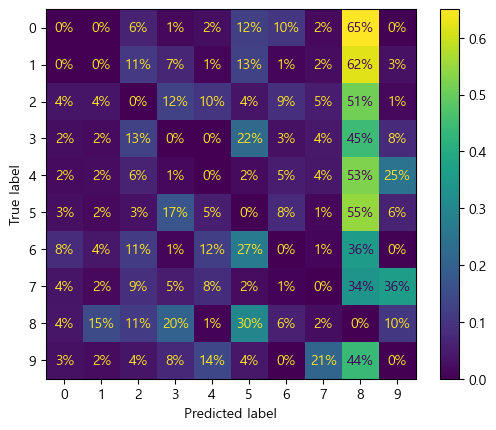

In [ ]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train,y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize='true',values_format=".0%")
plt.show()

이제 분류기가 어떤 종류의 오류를 범하는지 훨씬 더 명확하게 확인할 수 있다. 클래스 8의 열이 매우 밝아진 것으로 많은 이미지가 8로 잘못 분류되었음을 알 수 있다. 사실 이는 거의 모든 클래스에서 가장 많이 발생하는 분류 오류이다. 하지만 이 그래프에서 백분율을 해석하는 방법에 주의해야 한다. 올바른 예측을 제외했다는 점을 기억해야 한다. 예를 들어 7번 행의 9번 열의 36%는 모든 7 이미지 중 36%가 9로 잘못 분류되었다는 뜻이 아니라, **모델이 7 이미지에서 발생한 오류 중 36%가 9로 잘못 분류되었다는 의미**이다.

오차 행렬을 분석하면 분류기의 성능 향상 방안에 관한 인사이트를 얻을 수 있다. 여기서는 8로 잘못 분류되는 것을 줄이도록 개선할 필요가 있다. 예를 들어 8처럼 보이지만, 실제로 8은 아닌 숫자의 훈련 데이터를 더 많이 모아서 실제 8과 구분하도록 분류기를 학습시킬 수 있다. 또는 분류기에 도움될 만한 특성을 더 찾아볼 수 있다.

각각의 오류를 분석해보면 분류기가 무슨 일을 하는지, 왜 잘못되었는지 인사이트를 얻을 수 있다. 예시로 오차 행렬 스타일로 3과 5의 샘플을 그려본다.

In [ ]:
cl_a,cl_b ='3','5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

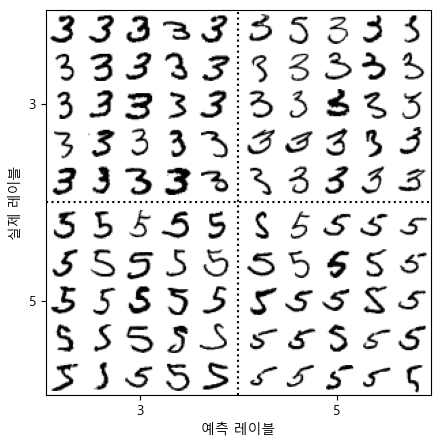

In [ ]:
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("예측 레이블")
plt.ylabel("실제 레이블")
plt.show()

분류기가 잘못 분류한 숫자의 일부는 실제로 분류하기 어려울 것처럼 보인다. 그러나 대부분의 잘못 분류된 이미지는 확실한 오류로 보이며 분류기가 실수한 이유를 이해하기 어렵다. 3과 5의 주요 차이는 위쪽 선과 아래쪽 호를 이어주는 작은 직선의 위치이다. 숫자 3을 쓸 때 연결 부위가 조금 왼쪽으로 치우치면 분류기가 5로 분류하고 그 반대도 마찬가지이다. 다른 말로 하면 분류기는 이미지의 위치나 회전 방향에 매우 민감하다. 3과 5의 오류를 줄이는 한 가지 방법은 이미지를 중앙에 위치시키고 회전되어 있지 않도록 전처리하는 것이다. 이보다 훨씬 간단한 접근 방식은 훈련 이미지를 약간 이동시키거나 회전된 변형 이미지로 훈련 집합을 보강하는 것이다. 이렇게 하면 모델이 이러한 번형에 더 잘 견디도록 학습하게 된다. 이를 **데이터 증식(data augmentation)** 이라고 한다.

---

## 3.6 다중 레이블 분류

지금까지는 각 샘플이 하나의 클래스에만 할당되었다. 하지만 분류기가 **샘플마다 여러 개의 클래스를 출력**해야 할 때도 있다. 얼굴 인식 분류기를 생각해보자. 같은 사진에 여러 사람이 등장한다면, 인식된 사람마다 하나씩 꼬리표,태그를 붙여야 한다. 분류기가 앨리스, 밥, 찰리 세 얼굴을 인식하도록 훈련되었다고 가정해보자. 분류기가 앨리스와 찰리가 있는 사진을 본다면 [1,0,1]을 출력해야 할 것이다. 이처럼 여러 개의 이진 꼬리표를 출력하는 분류 시스템을 **다중 레이블 분류(Multilabel Classification)** 시스템이라고 한다.

여기서는 얼굴 인식 시스템을 만들려는 것이 아니므로, 학습을 위해 조금 더 간단한 예시를 살펴본다.

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2== 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train,y_multilabel);

이 코드는 각 숫자 이미지에 두 개의 타겟 레이블이 담긴 `y_multilabel` 배열을 만든다. 첫 번째는 숫자가 큰 값(7,8,9)인지 나타내고 두 번째는 홀수인지 나타낸다. 그 다음 코드는 `KNeighborsClassifier` 인스턴스를 만들고 다중 타겟 배열을 사용하여 훈련시킨다(`KNeighborsClassifier`는 다중 레이블 분류를 지원하지만 모든 분류기가 그런 것은 아니다).

이제 예측을 만들면 레이블이 두 개 출력된다.

In [ ]:
knn_clf.predict([some_digit])

array([[False,  True]])

올바르게 분류되었다. 숫자 5는 크지않고(`False`) 홀수(`True`)이다.

다중 레이블 분류기를 평가하는 방법은 많다. 적절한 지표는 프로젝트에 따라 다르다. 한 가지 방법은 각 레이블의 $F_1$ 점수를 구하고 간단하게 평균 점수를 계산하는 것이다. 다음 코드는 모든 레이블에 대한 $F_1$ 점수의 평균을 계산한다.

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf,X_train,y_multilabel,cv=3)
f1_score(y_multilabel,y_train_knn_pred,average='macro')

0.976410265560605

실제로는 아닐 수 있지만 이 코드는 모든 레이블의 가중치가 같다고 가정한 것이다. 특히 앨리스 사진이 밥이나 찰리 사진보다 훨씬 만다면 앨리스 사진에 대한 분류기의 점수에 더 높은 가중치를 둘 것이다. 간단한 방법은 레이블에 클래스의 **지지도(Support)** 를 가중치로 주는 것이다. 지지도란 타겟 레이블에 속한 샘플 수를 말한다. 이렇게 하려면 `f1_score()` 함수를 호출할 때 `average='weighted'`로 설정하면 된다.

`SVC`와 같이 기본적으로 다중 레이블 분류를 지원하지 않는 분류기를 사용하는 경우 한 가지 가능한 전략은 레이블당 하나의 모델을 학습시키는 것이다. 그러나 이 전략은 레이블 간의 의존성을 포착하기 어렵게 할 수 있다.

예를 들어 큰 숫자 (7,8 또는 9)는 짝수보다 홀수일 가능성이 두 배 더 높지만 '홀수' 레이블에 대한 분류기는 '큰 값' 레이블 분류기가 무엇을 예측했는지 알 수 없다. 이 문제를 해결하기 위해 모델을 체인(Chain)으로 구성할 수 있다. 한 모델이 예측을 할 때 입력 변수와 체인 앞에 있는 모델의 모든 예측을 사용한다.

사이킷런에는 바로 이 작업을 수행하는 `ClassifierChain` 클래스가 있다. 기본적으로 이 클래스는 훈련에 진짜 레이블을 사용하며 체인 내 위치에 따라 각 모델에 적절한 레이블을 공급한다. 하지만 `cv` 하이퍼파라미터를 지정하면 교차 검증을 사용하여 훈련 세트의 모든 샘플에 대해 훈련된 각 모델에서 Out-of-sample에 대한 예측을 얻고, 이러한 예측을 사용해 나중에 체인 안의 모든 모델을 훈련한다.

다음은 교차 검증 전략을 사용하여 `ClassifierChain`을 만들고 훈련하는 방법을 보여준다. 여기서도 속도를 높이기 위해 훈련 세트에서 처음 2000개 이미지만 사용한다.

In [ ]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(),cv=3,random_state=42)
chain_clf.fit(X_train[:2000],y_multilabel[:2000]);

이제 `ClassifierChain`을 사용해 예측을 만들 수 있다.

In [ ]:
chain_clf.predict([some_digit])

array([[0., 1.]])

---

## 3.7 다중 출력 분류

마지막으로 알아볼 분류 작업은 **다중 출력 분류(Multioutput Classification)** 이다. 이는 다중 레이블 분류에서 한 레이블이 다중 클래스가 될 수 있도록 일반화한 것이다. 즉, 값을 두 개 이상 가질 수 있다.

이를 설명하기 위해 이미지에서 잡음을 제겋는 시스템을 만들어본다. 이 시스템은 잡음이 많은 숫자 이미지를 입력으로 받아 깨끗한 숫자 이미지를 MNIST 이미지처럼 픽셀의 강도를 담은 배열로 출력한다. 분류기의 출력이 다중 레이블(픽셀 당 한 레이블)이고 각 레이블은 값을 0부터 255 픽셀 강도까지 가진다.

먼저 MNIST 이미지에서 추출한 훈련 세트와 테스트 세트에 넘파이의 `randint()` 함수를 사용하여 픽셀 강도에 잡음을 추가한다. 타겟 이미지는 원본 이미지가 될 것이다.

In [ ]:
np.random.seed(42)
noise = np.random.randint(0,100,(len(X_train),784))
X_train_mod = X_train + noise

noise = np.random.randint(0,100,(len(X_test),784))
X_test_mod = X_test + noise

y_train_mod = X_train
y_test_mod = X_test

테스트 세트에서 이미지를 하나 선택한다.

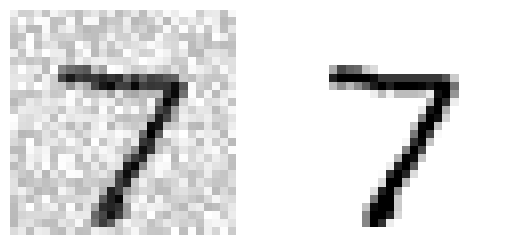

In [ ]:
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
plt.show()

여기서 테스트 데이터를 들여다보는 것이 잘못된 것임을 눈치채야 한다. 왼쪽이 잡음이 섞인 입력 이미지이고 오른쪽이 깨끗한 타겟 이미지이다. 분류기를 훈련시켜 이미지를 깨끗하게 만들어본다.

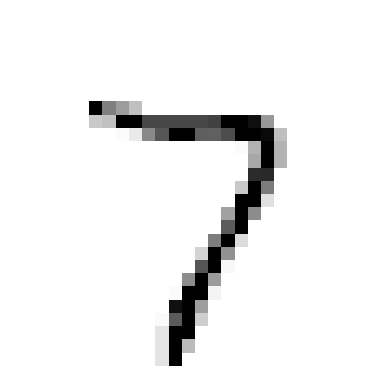

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod,y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

타겟과 매우 비슷하다.